<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4.5-transfer-learning-pytorch-tensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Transfer Learning y Fine-tuning con ResNet-18 y EfficientNet-B0 usando tensores de Pytorch

### Introduction:

**Tensores 3D:** Datos procesados directamente con PyTorch a partir de los **Espectrograma de Mel**, **Delta de primer del espectrograma** y **Espectrograma Coclear**. Esto resulta en un tensor de entrada con la estructura `[3, Frecuencia, Tiempo en frames]` cuyas dimensiones son `[3, 60,51]`.


In [ ]:
# Imports
#----------------------------------------------------------------
import os
import gc
import numpy as np
import glob
import torch
import random
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
#----------------------------------------------------------------
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchaudio import transforms as T
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from torch.cuda.amp import GradScaler, autocast
from google.colab import drive

In [ ]:
# Instalacion de Weights & Biases

!pip install wandb -q

# Import y Loging

import wandb; wandb.login()

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Fijación de semillas para reproducibilidad
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device en uso: cuda


In [ ]:
# Copiamos la carpeta entera de features desde Drive al disco ultrarrápido de Colab
#!cp -r /content/drive/MyDrive/ravdess_images_02/ /content/features_local
os.makedirs('/content/', exist_ok=True)
# Opcional: Si tienes un archivo .zip en Drive, es AÚN MÁS RÁPIDO copiar el .zip y descomprimirlo localmente:
!cp -r /content/drive/MyDrive/split_pytorch_tensors/ /content

In [ ]:
# Configuraciones y rutas
BASE_DIR_TENSOR = '/content/split_pytorch_tensors'
MODELS_SAVE_DIR = '/content/saved_models_TL_Pytorch'
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
# Batch por defecto = 64
BATCH_SIZE = 64
# Bandera para datos no preparados
already_normalized = True

In [ ]:
# Print root_dir content:
tensor_content = (os.listdir(BASE_DIR_TENSOR))
print(f"Contenido de {BASE_DIR_TENSOR}: {tensor_content}")

Contenido de /content/split_pytorch_tensors: ['val_tensors.pt', 'test_tensors.pt', 'train_tensors.pt']


### Dataloaders con nombres de clases y metadatos

Gracias a que guardamos un pack con metadatos, donde creamos un diccionario, asociando los indices a los nombres de clases. Podemos crear una clase personalziada que extrae nuestros tensores con sus respectivos nombres de clases, y dimensiones por cada conjuntos de datos.

### Estrategia de normalización y augmentation

**Normalización:**  
Los tensores exportados en el notebook `3.2` ya fueron normalizados con **z-score por muestra y canal** (`zscore_per_channel`). Por eso `already_normalized = True` y no se aplica una segunda normalización a nivel de dataset aquí. Aplicar `CHANNEL_MEAN/CHANNEL_STD` encima del z-score por muestra introduciría una doble normalización redundante que puede distorsionar la distribución de entrada.

**Augmentation online:**  
El notebook `3.2` ya añadió muestras extra de `surprised` con **ruido** y **shift temporal** durante la exportación. En consecuencia, aquí se usa **solo SpecAugment** (FrequencyMasking + TimeMasking) como augmentation online, únicamente sobre el split de entrenamiento. No se repiten ruido ni shift para evitar acumulación de augmentations.

**WeightedRandomSampler:**  
Dado que `surprised` ya está sobre-representada por la exportación offline, `WeightedRandomSampler` está desactivado por defecto (`use_weighted_sampler=False`). Se puede activar si se regeneran los tensores sin augmentation offline.


In [ ]:
SPLIT_FILES = {
    'train': 'train_tensors.pt',
    'val': 'val_tensors.pt',
    'test': 'test_tensors.pt',
}

def load_pack(split_name: str):
    path = os.path.join(BASE_DIR_TENSOR, SPLIT_FILES[split_name])
    if not os.path.exists(path):
        raise FileNotFoundError(f'No existe el archivo: {path}')
    return torch.load(path, map_location='cpu', weights_only=False)

# Cargamos los packs (aún no son tensores puros)
train_pack = load_pack('train')
val_pack = load_pack('val')
test_pack = load_pack('test')

# Verificamos las clases del diccionario dentro del pack
class_to_idx = train_pack['class_to_idx']
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
print('Clases:', class_names)
print('Shape train:', tuple(train_pack['x'].shape))

# CLASS_WEIGHTS siempre se calcula (es función de las etiquetas, no de la normalización)
def compute_class_weights(labels: torch.Tensor, num_classes: int):
    counts = torch.bincount(labels, minlength=num_classes).float()
    weights = counts.sum() / (counts * num_classes)
    return weights

CLASS_WEIGHTS = compute_class_weights(train_pack['y'], len(class_names))
print('Balance por clase:', torch.bincount(train_pack['y']).tolist())

# Normalización de canal solo si los tensores NO fueron pre-normalizados en la exportación.
# Con already_normalized=True los tensores ya tienen z-score por muestra (notebook 3.2),
# por lo que NO se aplica una segunda normalización a nivel de dataset.
if not already_normalized:
    MIN_STD = 1e-6

    def compute_channel_stats(x: torch.Tensor):
        x = x.float()
        mean = x.mean(dim=(0, 2, 3))
        std = x.std(dim=(0, 2, 3)).clamp_min(MIN_STD)
        return mean, std

    CHANNEL_MEAN, CHANNEL_STD = compute_channel_stats(train_pack['x'])
    print(f'CHANNEL_MEAN={CHANNEL_MEAN}, CHANNEL_STD={CHANNEL_STD}')


Clases: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Shape train: (7422, 3, 60, 51)
Balance por clase: [1178, 1178, 1178, 1178, 1100, 1178, 432]


In [ ]:
class TensorPackDataset(Dataset):
    """Dataset de tensores pre-exportados con z-score por muestra (notebook 3.2).

    Augmentation online: solo SpecAugment (FrequencyMasking + TimeMasking).
    El ruido y shift ya se aplicaron durante la exportación para 'surprised',
    por lo que NO se repiten aquí para evitar doble augmentation.
    Augmentation se aplica SOLO al split de entrenamiento (augment=True).
    """
    def __init__(self, pack, augment=False):
        self.x = pack['x'].float()  # [N, 3, n_mels, n_frames]
        self.y = pack['y'].long()
        self.augment = augment

        # SpecAugment solo para train (tamaño de entrada: 60 mel bins x 51 frames)
        if augment:
            self.spec_aug = nn.Sequential(
                T.FrequencyMasking(freq_mask_param=3),
                T.TimeMasking(time_mask_param=2)
            )

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        x = self.x[idx]
        y = self.y[idx]

        if self.augment:
            # SpecAugment espera [C, F, T] o [B, C, F, T]
            x = self.spec_aug(x)

        return x, y

In [ ]:
# Solo aumentamos el set de TRAIN. Val y Test deben quedar puros.
#
# Nota sobre WeightedRandomSampler:
# El dataset de train ya incluye muestras extra de 'surprised' (augmentation de exportación
# en notebook 3.2). Activar además WeightedRandomSampler duplicaría el sobre-muestreo de
# esa clase. Por eso use_weighted_sampler=False es el valor por defecto seguro.
# Si los tensores se regeneran SIN augmentation offline, se puede activar con True.

def build_dataloaders(batch_size=BATCH_SIZE, use_weighted_sampler=False):
    pin = torch.cuda.is_available()
    num_workers = 2 if torch.cuda.is_available() else 0

    train_ds = TensorPackDataset(train_pack, augment=True)
    val_ds = TensorPackDataset(val_pack, augment=False)
    test_ds = TensorPackDataset(test_pack, augment=False)

    sampler = None
    shuffle_train = True
    if use_weighted_sampler:
        sample_weights = CLASS_WEIGHTS[train_pack['y']]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle_train = False

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, shuffle=shuffle_train,
                              num_workers=num_workers, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)

    return train_loader, val_loader, test_loader, class_names, CLASS_WEIGHTS

train_loader, val_loader, test_loader, class_names, class_weights = build_dataloaders()


In [ ]:
# Weigths and biases | Configuración:

USE_WANDB = True
WANDB_PROJECT = "tcoe-transfer-no-aug"
WANDB_GROUP = "resnet18-and-effb0"

# Hiper parametros fijos


EPOCHS = 50



# Directorio Local para los mejores checkpoints:

CHECKPOINT_DIR = '/content/checkpoints_transfer_no_aug'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Matriz de experimentos:




### Model Factory

ResNet18 y Efficientnet-b0

In [ ]:
class TensorModelFactory:
  @staticmethod
  def get_model(model_name: str, num_classes: int, freeze_base: bool=True):
    if model_name == 'resnet18':
      model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
      # Adaptacion para input pequeño [3,60,51]
      model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
      model.maxpool = nn.Identity()
      if freeze_base:
        for param in model.parameters():
          param.requires_grad = False

      in_features = model.fc.in_features
      model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_features, num_classes))

    elif model_name == 'efficientnet_b0':
      model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)


      if freeze_base:
          for p in model.parameters():
              p.requires_grad = False

      in_f = model.classifier[1].in_features
      model.classifier = nn.Sequential(
          nn.Dropout(0.4),
          nn.Linear(in_f, num_classes)
      )

    else:
        raise ValueError(f"Modelo no soportado para tensor pipeline: {model_name}")

    return model.to(device)

### Entrenamiento de Red Neuronal

Funcion para entrenar con ResNet o Efficientnet-b0, las funciones de entrenamiento de modelos son muy similares, en ellas podremos configurar los parametros de la red, por ejemplo:
* Directorio donde guaramos  los modelos `save_path`,
* Numero de epocas `epochs`,
* Learning rate o taza de aprendizaje `lr`,
* Numero de intentos antes de detener el entrenamiento `patience`,
* Configuracion de los pesos `weight_decay`.


In [ ]:
def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def cleanup_state():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


HEAD_PREFIXES = ('fc', 'classifier', 'head')


def split_parameters(model, head_prefixes=HEAD_PREFIXES):
    head_params, backbone_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith(head_prefixes):
            head_params.append(param)
        else:
            backbone_params.append(param)
    return backbone_params, head_params


def build_optimizer(model, lr, backbone_lr=None, weight_decay=1e-2):
    backbone_params, head_params = split_parameters(model)
    if not backbone_params or backbone_lr is None:
        return optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=lr, weight_decay=weight_decay)

    return optim.AdamW(
        [
            {'params': backbone_params, 'lr': backbone_lr},
            {'params': head_params, 'lr': lr}
        ],
        weight_decay=weight_decay
    )


def train_model_tensor(
    model,
    train_loader,
    val_loader,
    save_path,
    epochs=50,
    lr=1e-4,
    backbone_lr=None,
    patience=5,
    weight_decay=1e-2,
    label_smoothing=0.05,
    max_grad_norm=1.0,
    class_weights=None
):
    if class_weights is not None:
        class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    optimizer = build_optimizer(model, lr=lr, backbone_lr=backbone_lr, weight_decay=weight_decay)

    # scheduler maximiza F1 macro
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    # mejor checkpoint por F1 macro
    best_val_f1 = -1.0
    trigger = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            if max_grad_norm is not None:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == y).sum().item()
            train_total += y.size(0)

        train_loss /= max(train_total, 1)
        train_acc = train_correct / max(train_total, 1)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        all_val_y, all_val_p = [], []

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    logits = model(x)
                    loss = criterion(logits, y)

                val_loss += loss.item() * x.size(0)
                preds = logits.argmax(dim=1)

                val_correct += (preds == y).sum().item()
                val_total += y.size(0)
                all_val_y.extend(y.cpu().numpy())
                all_val_p.extend(preds.cpu().numpy())

        val_loss /= max(val_total, 1)
        val_acc = val_correct / max(val_total, 1)
        val_f1_macro = f1_score(all_val_y, all_val_p, average='macro', zero_division=0)

        scheduler.step(val_f1_macro)
        lr_now = optimizer.param_groups[0]['lr']

        print(f"[{epoch+1:02d}/{epochs}] lr={lr_now:.1e} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f} f1m={val_f1_macro:.4f}")

        if val_f1_macro > best_val_f1:
            best_val_f1 = val_f1_macro
            torch.save(model.state_dict(), save_path)
            trigger = 0
        else:
            trigger += 1
            print(f"Early stop activado: {trigger}/{patience}")
            if trigger >= patience:
                print("Early stopping.")
                break

    return save_path


Ejecución de entrenamiento

In [ ]:
# Limpieza del estado para evitar resultados por memorizacion
set_global_seed(42)
cleanup_state()

In [ ]:
MODELS_SAVE_DIR = "/content/saved_models"
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
MODEL_ARCH_1 = 'efficientnet_b0'
exp_name_b0 = f"tensor{MODEL_ARCH_1}"

train_loader, val_loader, test_loader, class_names, class_weights = build_dataloaders()

phase1_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_b0}efficient_fase1.pth")

model = TensorModelFactory.get_model(MODEL_ARCH_1, num_classes=len(class_names), freeze_base=True)

best_phase1_eff = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase1_path,
    epochs=30,
    lr=1e-3,
    patience=4,
    class_weights=class_weights
)

print("Fase 1 mejor modelo:", best_phase1_eff)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s]


[01/30] lr=1.0e-03 | train_loss=1.8702 acc=0.2440 | val_loss=1.8339 acc=0.2727 f1m=0.2587
[02/30] lr=1.0e-03 | train_loss=1.7642 acc=0.2961 | val_loss=1.8631 acc=0.2620 f1m=0.2455
Early stop activado: 1/4
[03/30] lr=1.0e-03 | train_loss=1.7345 acc=0.3065 | val_loss=1.8467 acc=0.2656 f1m=0.2520
Early stop activado: 2/4
[04/30] lr=1.0e-03 | train_loss=1.7409 acc=0.2986 | val_loss=1.8325 acc=0.2919 f1m=0.2741
[05/30] lr=1.0e-03 | train_loss=1.7275 acc=0.3095 | val_loss=1.8361 acc=0.2871 f1m=0.2713
Early stop activado: 1/4
[06/30] lr=1.0e-03 | train_loss=1.7312 acc=0.3054 | val_loss=1.8226 acc=0.2931 f1m=0.2824
[07/30] lr=1.0e-03 | train_loss=1.7216 acc=0.3129 | val_loss=1.8278 acc=0.2919 f1m=0.2804
Early stop activado: 1/4
[08/30] lr=1.0e-03 | train_loss=1.7154 acc=0.3223 | val_loss=1.8430 acc=0.2871 f1m=0.2758
Early stop activado: 2/4
[09/30] lr=1.0e-03 | train_loss=1.7185 acc=0.3060 | val_loss=1.8650 acc=0.2644 f1m=0.2495
Early stop activado: 3/4
[10/30] lr=5.0e-04 | train_loss=1.7271 a

In [ ]:
# Descongelamiento de las capas de la CNN
phase2_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_b0}_fase2.pth")

model.load_state_dict(torch.load(best_phase1_eff, map_location=device, weights_only=True))
for p in model.parameters():
    p.requires_grad = True

best_phase2_eff = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase2_path,
    epochs=50,
    lr=1e-5,
    backbone_lr=1e-5,
    weight_decay=1e-3,
    patience=5,
    class_weights=class_weights
)

print("Fase 2 mejor modelo efficient:", best_phase2_eff)


[01/50] lr=1.0e-05 | train_loss=1.6996 acc=0.3189 | val_loss=1.8177 acc=0.2823 f1m=0.2690
[02/50] lr=1.0e-05 | train_loss=1.6850 acc=0.3281 | val_loss=1.8180 acc=0.2907 f1m=0.2753
[03/50] lr=1.0e-05 | train_loss=1.6522 acc=0.3367 | val_loss=1.8098 acc=0.2895 f1m=0.2735
Early stop activado: 1/5
[04/50] lr=1.0e-05 | train_loss=1.6452 acc=0.3469 | val_loss=1.7935 acc=0.2955 f1m=0.2800
[05/50] lr=1.0e-05 | train_loss=1.6284 acc=0.3627 | val_loss=1.7872 acc=0.3002 f1m=0.2868
[06/50] lr=1.0e-05 | train_loss=1.6113 acc=0.3557 | val_loss=1.7931 acc=0.3014 f1m=0.2848
Early stop activado: 1/5
[07/50] lr=1.0e-05 | train_loss=1.5967 acc=0.3568 | val_loss=1.7815 acc=0.2955 f1m=0.2801
Early stop activado: 2/5
[08/50] lr=1.0e-05 | train_loss=1.5875 acc=0.3634 | val_loss=1.7726 acc=0.3062 f1m=0.2907
[09/50] lr=1.0e-05 | train_loss=1.5668 acc=0.3867 | val_loss=1.7631 acc=0.3158 f1m=0.3006
[10/50] lr=1.0e-05 | train_loss=1.5625 acc=0.3853 | val_loss=1.7644 acc=0.3098 f1m=0.2951
Early stop activado: 1/5


Evalucion del modelo

Test Accuracy: 0.3936 | Test F1 macro: 0.3758

              precision    recall  f1-score   support

       angry       0.53      0.62      0.57       149
     disgust       0.32      0.37      0.34       149
     fearful       0.39      0.27      0.32       149
       happy       0.35      0.17      0.23       149
     neutral       0.34      0.45      0.39       143
         sad       0.50      0.46      0.48       149
   surprised       0.21      0.54      0.31        24

    accuracy                           0.39       912
   macro avg       0.38      0.41      0.38       912
weighted avg       0.40      0.39      0.39       912



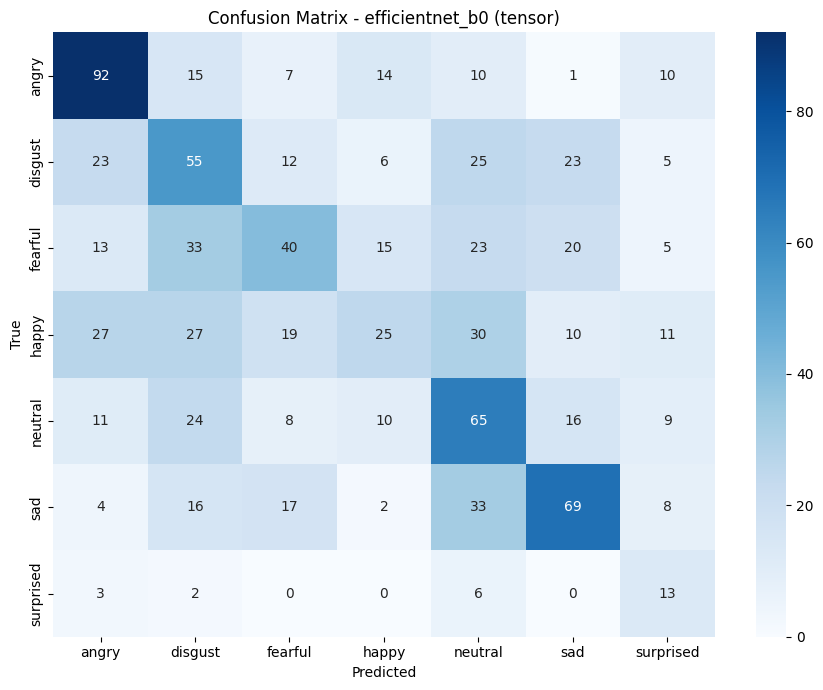

In [ ]:

def evaluate_tensor_model_eff(model_arch, model_path, test_loader, class_names):
    model = TensorModelFactory.get_model(model_arch, num_classes=len(class_names), freeze_base=False)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    all_y, all_p = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
            preds = logits.argmax(dim=1)

            all_y.extend(y.cpu().numpy())
            all_p.extend(preds.cpu().numpy())

    acc = accuracy_score(all_y, all_p)
    f1m = f1_score(all_y, all_p, average='macro', zero_division=0)
    print(f"Test Accuracy: {acc:.4f} | Test F1 macro: {f1m:.4f}\n")
    print(classification_report(all_y, all_p, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_y, all_p)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_arch} (tensor)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()
    gc.collect()

evaluate_tensor_model_eff(MODEL_ARCH_1, best_phase2_eff, test_loader, class_names)

### Fine tuning con Resnet18

In [ ]:
set_global_seed(42)
cleanup_state()

In [ ]:
MODELS_SAVE_DIR = "/content/saved_models"
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
MODEL_ARCH_2 = 'resnet18'
exp_name_18 = f"tensor_{MODEL_ARCH_2}"

train_loader, val_loader, test_loader, class_names, class_weights = build_dataloaders()

phase1_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_18}resnet_fase1.pth")

model = TensorModelFactory.get_model(MODEL_ARCH_2, num_classes=len(class_names), freeze_base=True)

best_fase1_18 = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase1_path,
    epochs=20,
    lr=1e-3,
    patience=6,
    class_weights=class_weights
)

print("Fase 1 mejor modelo:", best_fase1_18)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 238MB/s]


[01/20] lr=1.0e-03 | train_loss=1.9527 acc=0.2173 | val_loss=1.7843 acc=0.2823 f1m=0.2417
[02/20] lr=1.0e-03 | train_loss=1.7321 acc=0.3015 | val_loss=1.7354 acc=0.3206 f1m=0.2760
[03/20] lr=1.0e-03 | train_loss=1.6863 acc=0.3168 | val_loss=1.7311 acc=0.3134 f1m=0.2743
Early stop activado: 1/6
[04/20] lr=1.0e-03 | train_loss=1.6713 acc=0.3375 | val_loss=1.7058 acc=0.3397 f1m=0.3062
[05/20] lr=1.0e-03 | train_loss=1.6579 acc=0.3367 | val_loss=1.7307 acc=0.3194 f1m=0.2608
Early stop activado: 1/6
[06/20] lr=1.0e-03 | train_loss=1.6449 acc=0.3362 | val_loss=1.6994 acc=0.3385 f1m=0.2994
Early stop activado: 2/6
[07/20] lr=1.0e-03 | train_loss=1.6351 acc=0.3498 | val_loss=1.7231 acc=0.3289 f1m=0.2979
Early stop activado: 3/6
[08/20] lr=5.0e-04 | train_loss=1.6502 acc=0.3465 | val_loss=1.7065 acc=0.3254 f1m=0.3004
Early stop activado: 4/6
[09/20] lr=5.0e-04 | train_loss=1.6226 acc=0.3529 | val_loss=1.6905 acc=0.3481 f1m=0.3275
[10/20] lr=5.0e-04 | train_loss=1.6268 acc=0.3467 | val_loss=1.69

In [ ]:
phase2_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_18}_phase2_unfrozen.pth")

model.load_state_dict(torch.load(best_fase1_18, map_location=device, weights_only=True))
for p in model.parameters():
    p.requires_grad = True

best_fase2_18 = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase2_path,
    epochs=50,
    lr=1e-5,
    backbone_lr=1e-5,
    weight_decay=1e-3,
    patience=5,
    class_weights=class_weights
)

print("Fase 2 mejor modelo resnet:", best_fase2_18)

[01/50] lr=1.0e-05 | train_loss=1.5607 acc=0.3884 | val_loss=1.6255 acc=0.3876 f1m=0.3583
[02/50] lr=1.0e-05 | train_loss=1.4437 acc=0.4353 | val_loss=1.5939 acc=0.4091 f1m=0.3821
[03/50] lr=1.0e-05 | train_loss=1.3861 acc=0.4632 | val_loss=1.5579 acc=0.4211 f1m=0.4052
[04/50] lr=1.0e-05 | train_loss=1.3148 acc=0.5031 | val_loss=1.5404 acc=0.4474 f1m=0.4370
[05/50] lr=1.0e-05 | train_loss=1.2658 acc=0.5256 | val_loss=1.5205 acc=0.4498 f1m=0.4451
[06/50] lr=1.0e-05 | train_loss=1.2181 acc=0.5509 | val_loss=1.5096 acc=0.4569 f1m=0.4575
[07/50] lr=1.0e-05 | train_loss=1.1640 acc=0.5888 | val_loss=1.4947 acc=0.4569 f1m=0.4592
[08/50] lr=1.0e-05 | train_loss=1.1137 acc=0.6148 | val_loss=1.4897 acc=0.4653 f1m=0.4677
[09/50] lr=1.0e-05 | train_loss=1.0752 acc=0.6297 | val_loss=1.4946 acc=0.4677 f1m=0.4702
[10/50] lr=1.0e-05 | train_loss=1.0328 acc=0.6570 | val_loss=1.4792 acc=0.4737 f1m=0.4741
[11/50] lr=1.0e-05 | train_loss=0.9866 acc=0.6791 | val_loss=1.4743 acc=0.4821 f1m=0.4833
[12/50] lr

Test Accuracy: 0.4857 | Test F1 macro: 0.4831

              precision    recall  f1-score   support

       angry       0.61      0.68      0.65       149
     disgust       0.42      0.42      0.42       149
     fearful       0.45      0.42      0.44       149
       happy       0.50      0.42      0.45       149
     neutral       0.47      0.53      0.50       143
         sad       0.45      0.44      0.44       149
   surprised       0.46      0.50      0.48        24

    accuracy                           0.49       912
   macro avg       0.48      0.49      0.48       912
weighted avg       0.48      0.49      0.48       912



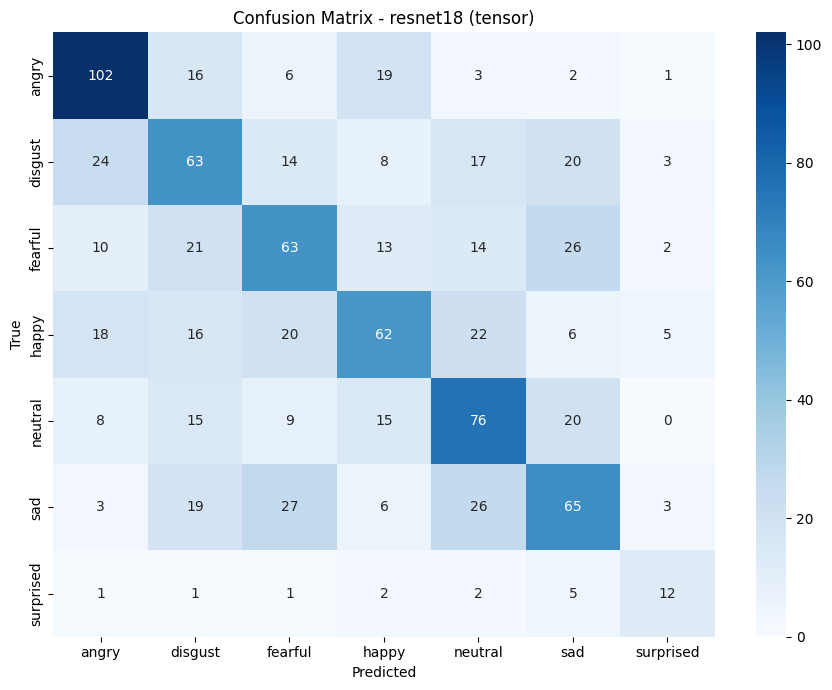

In [ ]:
def evaluate_tensor_model(model_arch, model_path, test_loader, class_names):
    model = TensorModelFactory.get_model(model_arch, num_classes=len(class_names), freeze_base=False)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    all_y, all_p = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
            preds = logits.argmax(dim=1)

            all_y.extend(y.cpu().numpy())
            all_p.extend(preds.cpu().numpy())

    acc = accuracy_score(all_y, all_p)
    f1m = f1_score(all_y, all_p, average='macro', zero_division=0)
    print(f"Test Accuracy: {acc:.4f} | Test F1 macro: {f1m:.4f}\n")
    print(classification_report(all_y, all_p, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_y, all_p)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_arch} (tensor)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()
    gc.collect()

evaluate_tensor_model(MODEL_ARCH_2, best_fase2_18, test_loader, class_names)

In [ ]:
set_global_seed(42)
cleanup_state()

In [ ]:
import shutil
# Guardamos los modelos para la siguiente fase (Late fusion)
output_filename = '/content/saved_models'
shutil.make_archive(output_filename, 'zip', MODELS_SAVE_DIR)

# Renombrar el archivo zip para que tenga la extensión .zip
# Esto es un workaround para make_archive que no agrega la extensión por defecto si el base_name ya tiene algo parecido a una extensión.
import os
os.rename('/content/saved_models.zip', '/content/saved_models_final.zip')

!cp /content/saved_models_final.zip /content/drive/MyDrive/saved_models_img_and_tensor.zip